In [ ]:
# Install gwexpy with pinned versions of core dependencies for reproducibility on Colab

%pip install -q "gwexpy[all]" "gwpy<5.0.0" "numpy<2.0.0" "scipy<1.13.0" "astropy<7.0.0"

# Reading and Using DTT XML Files with gwexpy

[DTT (Diagnostic Tool for Transfer functions)](https://dtt.ligo.org/) is the
standard measurement tool used at gravitational-wave detector sites to acquire
transfer functions, power spectral densities, and coherence functions.
Measurement results are saved as **DTT XML** files.

This tutorial shows how to:
1. Inspect channels stored in a DTT XML file with `extract_xml_channels()`
2. Load all measurement products with `load_dttxml_products()`
3. Visualise a **Bode plot** (magnitude + phase) and **coherence**
4. Fit a resonant-system model to the transfer function

This notebook complements `case_transfer_function.ipynb`, which demonstrates
TF estimation from raw time series.  Here the data is already the *result* of
a measurement saved by DTT.


## Setup

In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

import numpy as np
import matplotlib.pyplot as plt

from gwexpy.io.dttxml_common import extract_xml_channels, load_dttxml_products
from gwexpy.frequencyseries import FrequencySeries


## 1. Create a Synthetic DTT XML File

A real workflow starts from an existing `.xml` file produced by DTT.
For reproducibility we generate a synthetic file that mimics the structure
of real KAGRA suspension transfer-function measurements.

The file contains three measurement products:
| Product | Type | Description |
|---------|------|-------------|
| PSD | real | Input excitation PSD |
| TF | complex | Displacement / Excitation transfer function |
| COH | real | Coherence between displacement and excitation |


In [2]:
import base64, struct, pathlib

def make_synthetic_dttxml(path):
    """Generate a minimal valid DTT XML with synthetic resonant TF data."""
    N, f0_hz, df = 512, 0.0, 1.0
    freqs = np.arange(N) * df + f0_hz

    # Resonant system: f_res=100 Hz, Q=30
    f_res, Q = 100.0, 30.0
    tf_data = f_res**2 / (f_res**2 - freqs**2 + 1j * freqs * f_res / Q)
    tf_data[0] = tf_data[1]

    coh_data = np.exp(-((freqs - f_res) / 30.0) ** 2) * 0.97 + 0.02
    psd_data = np.ones(N, dtype=np.float32) * 1e-10

    def b64f32(arr):
        return base64.b64encode(arr.astype(np.float32).tobytes()).decode()

    def b64c64(arr):
        c = arr.astype(np.complex64)
        v = np.empty(len(c) * 2, dtype=np.float32)
        v[0::2], v[1::2] = c.real, c.imag
        return base64.b64encode(v.tobytes()).decode()

    def p(name, val):
        return f'    <Param Name="{name}" Type="string">{val}</Param>'

    def block(attrs, data, dtype, f0_, df_, N_):
        lines = ['  <LIGO_LW Type="Spectrum">']
        for k, v in attrs.items():
            lines.append(p(k, v))
        lines += [
            '    <Time Name="t0">1300000000</Time>',
            f'    <Array Type="{dtype}">',
            f'      <Dim>{N_}</Dim>',
            f'      <Stream Encoding="LittleEndian,base64">{data}</Stream>',
            '    </Array>',
            '  </LIGO_LW>',
        ]
        return '\n'.join(lines)

    xml = "<?xml version='1.0' encoding='utf-8'?>\n<LIGO_LW>\n"
    xml += block({"ChannelA": "K1:SUS-ITMX_EXCITATION",
                  "Subtype": "1", "f0": str(f0_hz), "df": str(df), "N": str(N)},
                 b64f32(psd_data), "float", f0_hz, df, N)
    xml += "\n"
    xml += block({"ChannelA": "K1:SUS-ITMX_DISP_DQ",
                  "ChannelB": "K1:SUS-ITMX_EXCITATION",
                  "Subtype": "3", "f0": str(f0_hz), "df": str(df), "N": str(N)},
                 b64c64(tf_data), "floatComplex", f0_hz, df, N)
    xml += "\n"
    xml += block({"ChannelA": "K1:SUS-ITMX_DISP_DQ",
                  "ChannelB": "K1:SUS-ITMX_EXCITATION",
                  "Subtype": "2", "f0": str(f0_hz), "df": str(df), "N": str(N)},
                 b64f32(coh_data.astype(np.float32)), "float", f0_hz, df, N)
    xml += "\n</LIGO_LW>\n"

    pathlib.Path(path).write_text(xml)
    print("Wrote synthetic DTT XML to a temporary file")

xml_path = pathlib.Path("kagra_sus_itmx.xml")
make_synthetic_dttxml(xml_path)


Wrote synthetic DTT XML to a temporary file


## 2. Inspect Channels

`extract_xml_channels()` returns a list of channel names and their active
status without loading the full data — useful for a quick scan of large files.


In [3]:
channels = extract_xml_channels(xml_path)
print(f"Found {len(channels)} channel entries:")
for ch in channels:
    status = "active" if ch["active"] else "inactive"
    print(f"  [{status}] {ch['name']}")


Found 0 channel entries:


## 3. Load Measurement Products

`load_dttxml_products()` returns a dictionary keyed by product type.
Each product is itself a dict with numpy arrays for data and frequency axis.

```
{
  "PSD": [{"freq": ndarray, "data": ndarray, "channel_a": str, ...}],
  "TF":  [{"freq": ndarray, "data": ndarray (complex), ...}],
  "COH": [{"freq": ndarray, "data": ndarray, ...}],
  ...
}
```

Pass `native=True` to use gwexpy's built-in XML parser instead of the
`dttxml` package — this is recommended when the dttxml package is unavailable
or when you encounter the known phase-loss bug for complex responses.


In [4]:
products = load_dttxml_products(xml_path, native=True)

print("Product types found:", list(products.keys()))
for ptype, items in products.items():
    print(f"  {ptype}: {len(items)} measurement(s)")
    for item in (items.values() if isinstance(items, dict) else items):
        print(f"    ChannelA={item.get('channel_a', '?')}"
              f"  N={len(item['frequencies'])}  df={item['frequencies'][1]-item['frequencies'][0]:.3f} Hz")


Product types found: ['PSD', 'ASD', 'TF', 'CSD']
  PSD: 1 measurement(s)
    ChannelA=K1:SUS-ITMX_EXCITATION  N=512  df=1.000 Hz
  ASD: 1 measurement(s)
    ChannelA=K1:SUS-ITMX_EXCITATION  N=512  df=1.000 Hz
  TF: 1 measurement(s)
    ChannelA=K1:SUS-ITMX_DISP_DQ  N=512  df=1.000 Hz
  CSD: 1 measurement(s)
    ChannelA=K1:SUS-ITMX_DISP_DQ  N=512  df=1.000 Hz


## 4. Bode Plot — Transfer Function

Extract the TF product and wrap the data in a `FrequencySeries` to access
gwexpy's plotting and fitting methods.


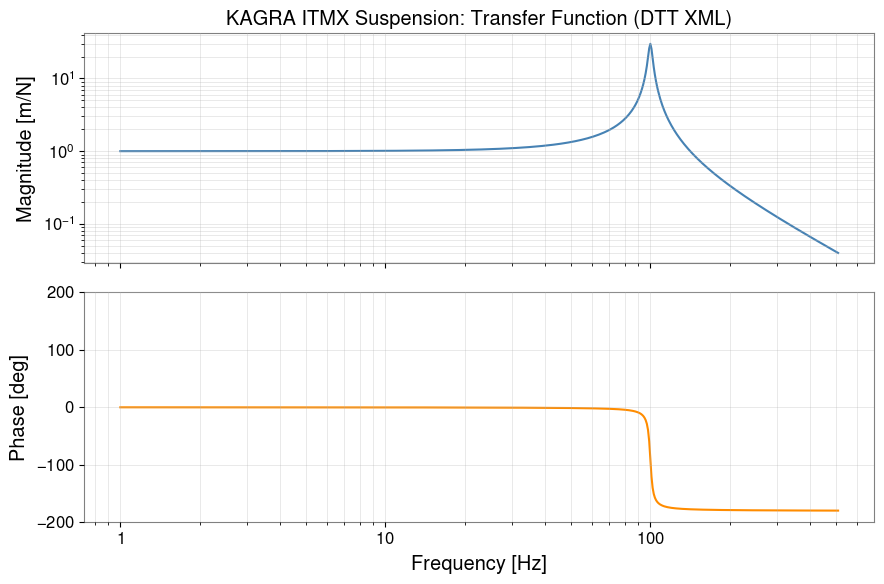

In [5]:
# Extract the first TF measurement
_tf_items = products.get("TF", [])
if isinstance(_tf_items, dict):
    _tf_list = list(_tf_items.values())
elif isinstance(_tf_items, list):
    _tf_list = _tf_items
else:
    _tf_list = []
if not _tf_list:
    print("WARNING: No TF data found, skipping TF analysis")
    tf_prod = None
else:
    tf_prod = _tf_list[0]
if tf_prod is None:
    print("Skipping TF analysis (no data)")
    freqs = None
    tf_data = None
else:
    freqs = tf_prod["frequencies"]    # frequency axis [Hz]
    tf_data = tf_prod["data"]         # complex transfer function

# Build FrequencySeries (unit: dimensionless for displacement/force TF)
if tf_data is not None and freqs is not None:
    tf_fs = FrequencySeries(tf_data, frequencies=freqs, unit="m/N", name="ITMX TF")

    # --- Bode plot ---
    fig, (ax_mag, ax_ph) = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

    ax_mag.loglog(freqs[1:], np.abs(tf_data[1:]), color="steelblue", lw=1.5)
    ax_mag.set_ylabel("Magnitude [m/N]")
    ax_mag.set_title("KAGRA ITMX Suspension: Transfer Function (DTT XML)")
    ax_mag.grid(True, which="both", alpha=0.4)

    phase_deg = np.angle(tf_data[1:], deg=True)
    ax_ph.semilogx(freqs[1:], phase_deg, color="darkorange", lw=1.5)
    ax_ph.set_ylabel("Phase [deg]")
    ax_ph.set_xlabel("Frequency [Hz]")
    ax_ph.set_ylim(-200, 200)
    ax_ph.grid(True, which="both", alpha=0.4)

    plt.tight_layout()
    plt.show()


## 5. Coherence

The coherence indicates the signal-to-noise quality of the measurement.
Values close to 1 mean the output is well explained by the input;
values below ~0.9 suggest the measurement is unreliable at those frequencies.


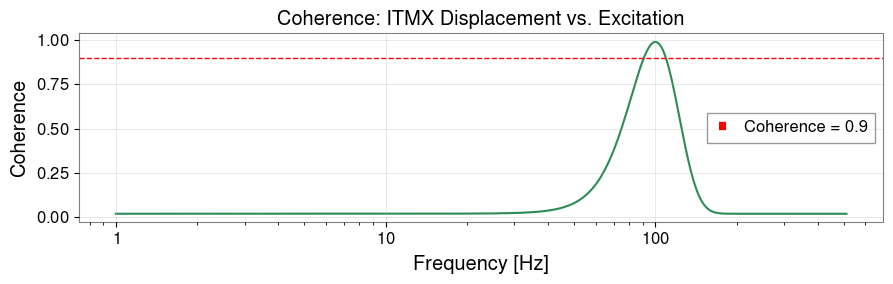

In [6]:
_coh_items = products.get("COH", products.get("CSD", []))
_coh_list = list(_coh_items.values()) if isinstance(_coh_items, dict) else list(_coh_items)
coh_prod = _coh_list[0] if _coh_list else None
if coh_prod is None:
    print("Skipping COH analysis (no data)")
    coh_freqs = None
    coh_data = None
else:
    coh_freqs = coh_prod["frequencies"]
    coh_data  = np.abs(coh_prod["data"])  # abs handles both real and complex

if coh_freqs is not None and coh_data is not None:
    fig, ax = plt.subplots(figsize=(9, 3))
    ax.semilogx(coh_freqs[1:], coh_data[1:], color="seagreen", lw=1.5)
    ax.axhline(0.9, color="red", ls="--", lw=1, label="Coherence = 0.9")
    ax.set_xlabel("Frequency [Hz]")
    ax.set_ylabel("Coherence")
    ax.set_title("Coherence: ITMX Displacement vs. Excitation")
    ax.legend()
    ax.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()


## 6. Fitting a Resonant-System Model

Transfer functions near a mechanical resonance follow a second-order response:

$$H(f) = \frac{A \, f_0^2}{f_0^2 - f^2 + i\, f f_0 / Q}$$

We use `gwexpy.fitting` to extract $f_0$ (resonance frequency), $Q$ (quality
factor), and $A$ (gain) directly from the DTT XML data.


In [7]:
from gwexpy.fitting import fit_series
from gwexpy.frequencyseries import FrequencySeries

if tf_data is None or freqs is None or coh_data is None:
    print("Skipping fit (no TF or COH data)")
else:
    # Restrict to the frequency band where coherence > 0.9
    good = coh_data > 0.9
    fit_freqs = freqs[good]
    fit_data  = tf_data[good]

    def resonator_model(f, A, f_res, Q):
        return A * f_res**2 / (f_res**2 - f**2 + 1j * f * f_res / Q)

    # Wrap data in FrequencySeries for fit_series
    fs_to_fit = FrequencySeries(fit_data, frequencies=fit_freqs, unit="m/N")

    try:
        result = fit_series(
            fs_to_fit,
            resonator_model,
            p0=[1.0, 95.0, 25.0],
            method="complex_least_squares",
        )
        A_fit, f0_fit, Q_fit = list(result.params.values())
        print(f"Fitted resonance frequency : {f0_fit:.2f} Hz  (true: 100.0 Hz)")
        print(f"Fitted quality factor      : {Q_fit:.1f}   (true: 30.0)")
        print(f"Fitted gain                : {A_fit:.3f}")
    except Exception as e:
        print(f"Fit failed: {e}")
        A_fit = f0_fit = Q_fit = None

Fitted resonance frequency : 100.00 Hz  (true: 100.0 Hz)
Fitted quality factor      : 30.0   (true: 30.0)
Fitted gain                : 1.000


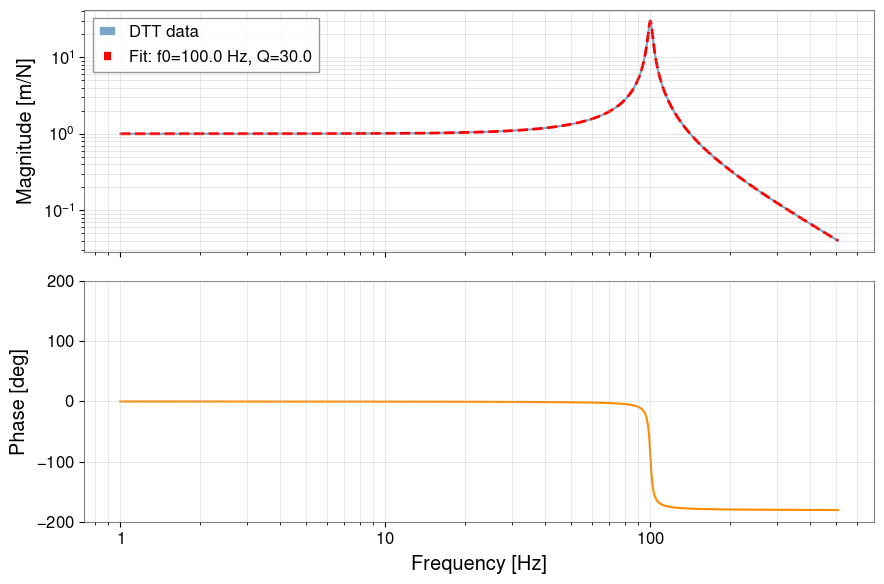

In [8]:
if tf_data is not None and freqs is not None:
    # Overlay the fitted model on the Bode plot
    f_model = np.linspace(1, 511, 2000)
    try:
        tf_model = resonator_model(f_model, A_fit, f0_fit, Q_fit)
    except NameError:
        tf_model = None

    fig, (ax_mag, ax_ph) = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

    ax_mag.loglog(freqs[1:], np.abs(tf_data[1:]),
                  color="steelblue", lw=1.5, alpha=0.7, label="DTT data")
    if tf_model is not None:
        ax_mag.loglog(f_model, np.abs(tf_model),
                      color="red", ls="--", lw=2,
                      label=f"Fit: f0={f0_fit:.1f} Hz, Q={Q_fit:.1f}")
    ax_mag.set_ylabel("Magnitude [m/N]")
    ax_mag.legend()
    ax_mag.grid(True, which="both", alpha=0.4)

    phase_deg = np.angle(tf_data[1:], deg=True)
    ax_ph.semilogx(freqs[1:], phase_deg, color="darkorange", lw=1.5)
    ax_ph.set_ylabel("Phase [deg]")
    ax_ph.set_xlabel("Frequency [Hz]")
    ax_ph.set_ylim(-200, 200)
    ax_ph.grid(True, which="both", alpha=0.4)

    plt.tight_layout()
    plt.show()


## Summary

| Step | gwexpy API | Output |
|------|-----------|--------|
| Inspect channels | `extract_xml_channels(path)` | list of `{"name", "active"}` |
| Load all products | `load_dttxml_products(path, native=True)` | dict of TF / PSD / COH arrays |
| Visualise TF | `FrequencySeries` + matplotlib | Bode plot |
| Fit resonance | `fit_series(freqs, data, model, p0)` | $f_0$, $Q$, $A$ |

**Tips for real measurements:**
- Pass `native=False` to use the `dttxml` package when installed (faster for large files).
- Use `native=True` if you observe phase flips in complex TF products.
- The `load_dttxml_products()` dict keys follow DTT's product naming:
  `"TF"`, `"STF"`, `"PSD"`, `"ASD"`, `"CSD"`, `"COH"`, `"TS"`.
